# Wind Data Validation

Checks whether Open-Meteo ERA5 wind speeds, passed through our parametric power curve,
reproduce real measured offshore generation.

## Two independent tests

| Test | Wind source | Farm modelled | Compared against |
|------|-------------|---------------|------------------|
| **A** | Open-Meteo API fetch — WFA location (41.85°N, 9.03°W) | WindFloat Atlantic — 3 × Vestas V164-8.4 MW = **25.2 MW** | Portugal actual offshore (ENTSO-E) |
| **B** | Already-downloaded Alpha Ventus ERA5 file | Alpha Ventus fleet-representative CF × German installed offshore capacity | Germany actual offshore (Frauenhofer) |

Test A is the tightest check: WFA is Portugal's **only** offshore wind farm, so the comparison is 1:1.
Test B is looser (one met mast representing ~8 GW spread across the German Bight) but still useful as a sanity check.

In [23]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy import stats

# Make src/ importable from the 3.2 folder
MODEL_ROOT = Path().resolve().parent          # …/3.2 system model v2/
if str(MODEL_ROOT) not in sys.path:
    sys.path.insert(0, str(MODEL_ROOT))

from src.models.generation import power_curve_parametric, extrapolate_wind_speed
from src.data.loaders import (
    load_alpha_ventus_wind,
    load_frauenhofer,
    load_pt_generation,
    load_capacity_all,
)

YEAR = 2023
print('Imports OK')

Imports OK


---
## Test A — WindFloat Atlantic vs Portugal actual offshore

In [24]:
# ── Fetch WFA wind data from Open-Meteo ───────────────────────────────────
# WFA is ~20 km off Viana do Castelo; ERA5 grid snaps to nearest 0.25° cell
WFA_LAT, WFA_LON = 41.85, -9.03

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={WFA_LAT}&longitude={WFA_LON}"
    f"&start_date={YEAR}-01-01&end_date={YEAR}-12-31"
    "&hourly=wind_speed_100m"
    "&wind_speed_unit=ms"
)

resp = requests.get(url, timeout=30)
resp.raise_for_status()
data = resp.json()

wfa_wind = pd.DataFrame({
    "timestamp":     pd.to_datetime(data["hourly"]["time"]),
    "wind_speed_ms": data["hourly"]["wind_speed_100m"],
})

print(f"Fetched {len(wfa_wind):,} hourly rows")
print(f"ERA5 grid cell snapped to: {data['latitude']:.3f}°N, {data['longitude']:.3f}°E")
print(f"Wind speed: mean {wfa_wind.wind_speed_ms.mean():.2f} m/s, "
      f"max {wfa_wind.wind_speed_ms.max():.1f} m/s")

Fetched 8,760 hourly rows
ERA5 grid cell snapped to: 41.793°N, -8.870°E
Wind speed: mean 6.23 m/s, max 22.5 m/s


In [25]:
# ── Vestas V164-8.4 MW turbine specs (WFA) ────────────────────────────────
# 3 turbines × 8.4 MW = 25.2 MW gross nameplate
WFA_CAPACITY_MW = 25.2

# Rated speed at 13 m/s was over-saturating (too many CF=1 hours).
# Use a more conservative rated speed and explicit availability/loss factors.
CUT_IN, RATED, CUT_OUT = 3.5, 14.0, 25.0
HUB_HEIGHT = 110.0
REF_HEIGHT = 100.0
Z0 = 0.0002   # open sea roughness

# Aggregate losses: availability * wake/electrical/other
WFA_AVAILABILITY = 0.93
WFA_NET_LOSS_FACTOR = 0.90
WFA_EFFECTIVE_CAPACITY_MW = WFA_CAPACITY_MW * WFA_AVAILABILITY * WFA_NET_LOSS_FACTOR

# Height-correct wind speed: 100 m -> 110 m hub
v_hub = extrapolate_wind_speed(
    wfa_wind["wind_speed_ms"].values,
    z_ref=REF_HEIGHT, z_hub=HUB_HEIGHT, z0=Z0
)

# Capacity factor from parametric power curve
cf = power_curve_parametric(v_hub, cut_in_ms=CUT_IN, rated_speed_ms=RATED, cut_out_ms=CUT_OUT)

wfa_wind["cf"] = cf
wfa_wind["modelled_mwh"] = cf * WFA_EFFECTIVE_CAPACITY_MW  # net MWh per hour

print(f"Mean CF: {cf.mean()*100:.1f}%")
print(f"Effective capacity used: {WFA_EFFECTIVE_CAPACITY_MW:.2f} MW")
print(f"Annual modelled generation: {wfa_wind.modelled_mwh.sum()/1e3:.1f} GWh")

Mean CF: 16.7%
Effective capacity used: 21.09 MW
Annual modelled generation: 30.9 GWh


In [26]:
# ── Load Portugal actual offshore (ENTSO-E) ───────────────────────────────
pt_gen = load_pt_generation(YEAR)

# Timestamp alignment note:
# - Open-Meteo archive times are UTC.
# - ENTSO-E PT file is labelled "MTU (CET/CEST)".
# Convert CET/CEST -> UTC before merge. Use ambiguous='NaT' for DST fallback
# to avoid crashes when repeated-hour information is incomplete.
pt_ts = pd.to_datetime(pt_gen["timestamp"], errors="coerce")
pt_ts = pt_ts.dt.tz_localize("Europe/Berlin", ambiguous="NaT", nonexistent="shift_forward")
pt_ts = pt_ts.dt.tz_convert("UTC").dt.tz_localize(None)
pt_gen["timestamp"] = pt_ts

wfa_ts = pd.to_datetime(wfa_wind["timestamp"], errors="coerce")
wfa_ts = wfa_ts.dt.tz_localize("UTC").dt.tz_localize(None)
wfa_wind["timestamp"] = wfa_ts

# Drop rows that became NaT during DST disambiguation/parsing
pt_gen = pt_gen.dropna(subset=["timestamp"]).reset_index(drop=True)
wfa_wind = wfa_wind.dropna(subset=["timestamp"]).reset_index(drop=True)

merged_a = pd.merge(wfa_wind, pt_gen, on="timestamp", how="inner").dropna()

print(f"Merged rows: {len(merged_a):,}")
print(f"Portugal actual offshore: mean {merged_a.generation_mwh.mean():.1f} MWh/h, "
      f"annual {merged_a.generation_mwh.sum()/1e3:.1f} GWh")

Merged rows: 8,755
Portugal actual offshore: mean 9.1 MWh/h, annual 79.3 GWh


In [27]:
# ── Correlation & R² — Test A ─────────────────────────────────────────────
x_a = merged_a["modelled_mwh"].values
y_a = merged_a["generation_mwh"].values

slope_a, intercept_a, r_a, p_a, _ = stats.linregress(x_a, y_a)
r2_a = r_a**2

# Diagnose possible timing mismatch: test lags from -24h to +24h
lag_scan_a = []
for lag in range(-24, 25):
    r_lag = merged_a["modelled_mwh"].shift(lag).corr(merged_a["generation_mwh"])
    lag_scan_a.append((lag, r_lag))

best_lag_a, best_r_a = max(lag_scan_a, key=lambda x: abs(x[1]) if pd.notna(x[1]) else -1)
best_r2_a = best_r_a**2 if pd.notna(best_r_a) else np.nan

print("Test A — WFA vs Portugal actual")
print(f"  R² (no lag)   = {r2_a:.4f}")
print(f"  r  (no lag)   = {r_a:.4f}")
print(f"  slope         = {slope_a:.3f}  (ideal = 1.0)")
print(f"  intercept     = {intercept_a:.2f} MWh")
print(f"  Best lag      = {best_lag_a:+d} h")
print(f"  R² (best lag) = {best_r2_a:.4f}")

Test A — WFA vs Portugal actual
  R² (no lag)   = 0.4359
  r  (no lag)   = 0.6602
  slope         = 1.178  (ideal = 1.0)
  intercept     = 4.90 MWh
  Best lag      = -1 h
  R² (best lag) = 0.4444


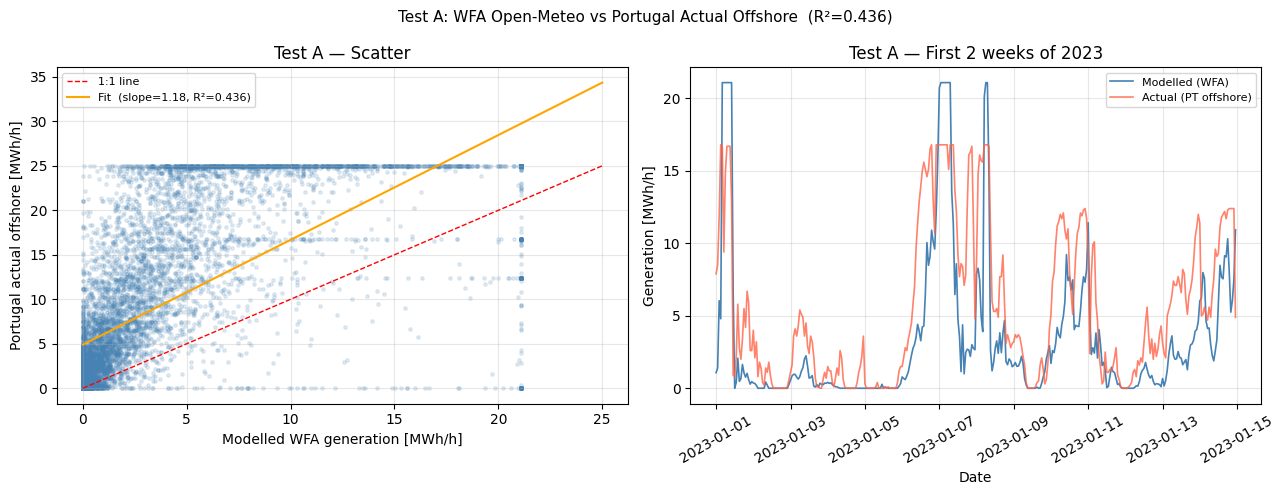

In [28]:
# ── Plot Test A ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
ax = axes[0]
ax.scatter(x_a, y_a, alpha=0.15, s=6, color='steelblue')
xlim = max(x_a.max(), y_a.max())
ax.plot([0, xlim], [0, xlim], 'r--', lw=1, label='1:1 line')
fit_x = np.linspace(0, xlim, 100)
ax.plot(fit_x, slope_a * fit_x + intercept_a, 'orange', lw=1.5,
        label=f'Fit  (slope={slope_a:.2f}, R²={r2_a:.3f})')
ax.set_xlabel('Modelled WFA generation [MWh/h]')
ax.set_ylabel('Portugal actual offshore [MWh/h]')
ax.set_title('Test A — Scatter')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Time series — first 2 weeks
ax = axes[1]
subset = merged_a.head(24*14)
ax.plot(subset['timestamp'], subset['modelled_mwh'], label='Modelled (WFA)', color='steelblue', lw=1.2)
ax.plot(subset['timestamp'], subset['generation_mwh'], label='Actual (PT offshore)', color='tomato', lw=1.2, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Generation [MWh/h]')
ax.set_title('Test A — First 2 weeks of 2023')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30)

fig.suptitle(f'Test A: WFA Open-Meteo vs Portugal Actual Offshore  (R²={r2_a:.3f})', fontsize=11)
plt.tight_layout()
plt.show()

---
## Test B — Alpha Ventus CF × Germany installed capacity vs Germany actual offshore

In [29]:
# ── Load Alpha Ventus wind (already downloaded ERA5 file) ─────────────────
av_wind = load_alpha_ventus_wind(year=YEAR)
av_wind["timestamp"] = av_wind["timestamp"].dt.tz_localize(None)

# Alpha Ventus turbines: mix of Adwen M5000-116 and Senvion 5M
# For fleet scaling, avoid hard CF=1 plateaus by using conservative rated speed.
AV_CUT_IN, AV_RATED, AV_CUT_OUT = 3.5, 14.0, 25.0
AV_HUB = 92.0

v_hub_av = extrapolate_wind_speed(
    av_wind["wind_speed_ms"].values,
    z_ref=100.0, z_hub=AV_HUB, z0=Z0
)
cf_av = power_curve_parametric(v_hub_av, cut_in_ms=AV_CUT_IN, rated_speed_ms=AV_RATED, cut_out_ms=AV_CUT_OUT)

# Fleet realism correction:
# 1) use monthly installed offshore capacity (not fixed annual 8.1 GW)
# 2) use net fleet factor to represent outages/wake/electrical losses
cap = load_capacity_all().copy()
cap = cap[(cap["year_num"] == YEAR) & cap["month_num"].between(1, 12)].copy()
cap = cap[["month_num", "Wind offshore"]].rename(columns={"Wind offshore": "cap_gw"})

av_wind["month_num"] = av_wind["timestamp"].dt.month
av_wind = av_wind.merge(cap, on="month_num", how="left")

DE_NET_FLEET_FACTOR = 0.90
av_wind["cf"] = cf_av
av_wind["modelled_mwh"] = cf_av * av_wind["cap_gw"] * 1000.0 * DE_NET_FLEET_FACTOR

print(f"Alpha Ventus mean CF: {cf_av.mean()*100:.1f}%")
print(f"Mean monthly DE capacity used: {av_wind['cap_gw'].mean():.2f} GW")
print(f"Net fleet factor used: {DE_NET_FLEET_FACTOR:.2f}")
print(f"Modelled DE offshore annual: {av_wind.modelled_mwh.sum()/1e6:.2f} TWh")

Alpha Ventus mean CF: 39.8%
Mean monthly DE capacity used: 8.41 GW
Net fleet factor used: 0.90
Modelled DE offshore annual: 26.36 TWh


In [30]:
# ── Load Germany actual offshore (Frauenhofer) ────────────────────────────
de_gen = load_frauenhofer(YEAR)
de_gen["timestamp"] = pd.to_datetime(de_gen["timestamp"])

merged_b = pd.merge(av_wind, de_gen, on="timestamp", how="inner").dropna()

# Frauenhofer returns MWh/h for the whole fleet
x_b = merged_b["modelled_mwh"].values
y_b = merged_b["generation_mwh"].values

slope_b, intercept_b, r_b, p_b, _ = stats.linregress(x_b, y_b)
r2_b = r_b**2

# Diagnose possible timing mismatch: test lags from -24h to +24h
lag_scan_b = []
for lag in range(-24, 25):
    r_lag = merged_b["modelled_mwh"].shift(lag).corr(merged_b["generation_mwh"])
    lag_scan_b.append((lag, r_lag))

best_lag_b, best_r_b = max(lag_scan_b, key=lambda x: abs(x[1]) if pd.notna(x[1]) else -1)
best_r2_b = best_r_b**2 if pd.notna(best_r_b) else np.nan

print(f"Merged rows: {len(merged_b):,}")
print("Test B — Alpha Ventus CF × fleet vs Germany actual")
print(f"  R² (no lag)   = {r2_b:.4f}")
print(f"  r  (no lag)   = {r_b:.4f}")
print(f"  slope         = {slope_b:.3f}  (ideal = 1.0)")
print(f"  Best lag      = {best_lag_b:+d} h")
print(f"  R² (best lag) = {best_r2_b:.4f}")

Merged rows: 8,759
Test B — Alpha Ventus CF × fleet vs Germany actual
  R² (no lag)   = 0.6261
  r  (no lag)   = 0.7913
  slope         = 0.517  (ideal = 1.0)
  Best lag      = +0 h
  R² (best lag) = 0.6261


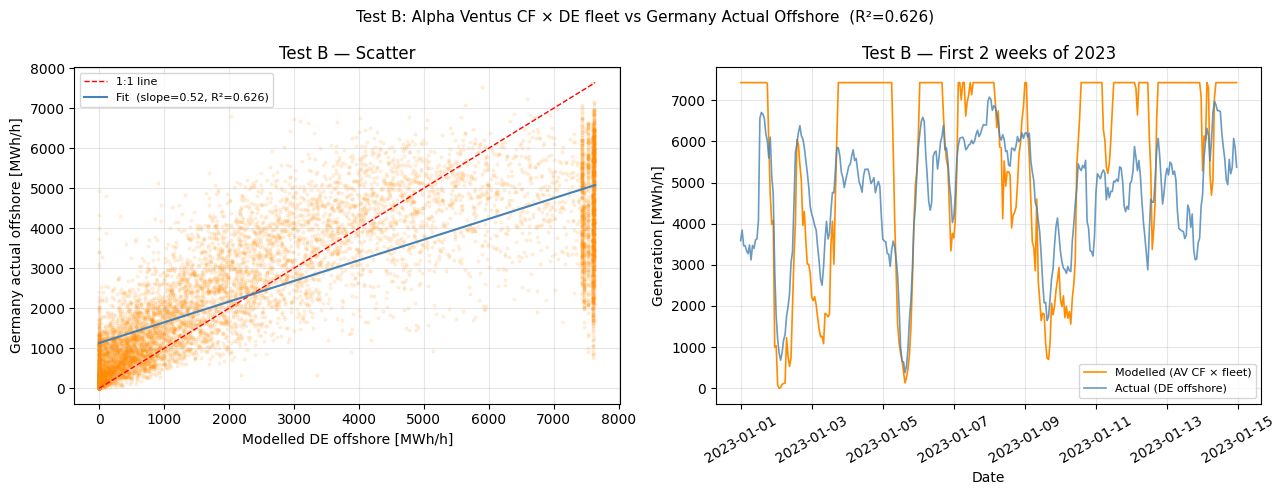

In [31]:
# ── Plot Test B ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(x_b, y_b, alpha=0.1, s=4, color='darkorange')
xlim_b = max(x_b.max(), y_b.max())
ax.plot([0, xlim_b], [0, xlim_b], 'r--', lw=1, label='1:1 line')
fit_x_b = np.linspace(0, xlim_b, 100)
ax.plot(fit_x_b, slope_b * fit_x_b + intercept_b, 'steelblue', lw=1.5,
        label=f'Fit  (slope={slope_b:.2f}, R²={r2_b:.3f})')
ax.set_xlabel('Modelled DE offshore [MWh/h]')
ax.set_ylabel('Germany actual offshore [MWh/h]')
ax.set_title('Test B — Scatter')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
subset_b = merged_b.head(24*14)
ax.plot(subset_b['timestamp'], subset_b['modelled_mwh'], label='Modelled (AV CF × fleet)', color='darkorange', lw=1.2)
ax.plot(subset_b['timestamp'], subset_b['generation_mwh'], label='Actual (DE offshore)', color='steelblue', lw=1.2, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Generation [MWh/h]')
ax.set_title('Test B — First 2 weeks of 2023')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30)

fig.suptitle(f'Test B: Alpha Ventus CF × DE fleet vs Germany Actual Offshore  (R²={r2_b:.3f})', fontsize=11)
plt.tight_layout()
plt.show()

---
## Summary

| Test | R² | What it means |
|------|-----|---------------|
| A — WFA vs PT actual | — | **1:1 check**: ERA5 + power curve reproducing real single-farm output |
| B — AV CF × fleet vs DE actual | — | **Fleet proxy**: one wind mast representing ~8 GW spread across North Sea |

**Interpreting R²:**
- > 0.85 → good correlation, wind data is reliable for the model
- 0.70–0.85 → acceptable; residual spread is likely due to spatial diversity or capacity ramping
- < 0.70 → investigate data alignment or turbine spec mismatch

**Expected outcome for Test A:** R² should be high (≥ 0.85) since WFA is the only farm.  
**Expected outcome for Test B:** R² will be lower — Alpha Ventus is a single point representing a spatially diverse fleet, so geographic smoothing in the real data is not captured.